# 本次模擬cmd log資訊

* 2026/06/19（00:49）開始模擬 
* 2026/06/19（10:10）結束
* Total run time 33639.50884 seconds
* 只保留最後一個iteration(146035)的迭代資訊和AMReX finalize(如下)


# 使用者設定

In [5]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

# FE layer range, unit: nm
FE_Z_LO_NM = 4.0
FE_Z_HI_NM = 9.0

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = -16.0
FE_X_HI_NM = 16.0

FE_Y_LO_NM = -16.0
FE_Y_HI_NM = 16.0

ALPHA = -2.5e9
BETA = 6.0e10
SMALL_GAMMA = 1.5e11
G11 = 1.0e-9
G44 = 1.0e-9


# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile
PLOTFILE_NAME = "plt00052034"

## Utils

In [3]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

# plot

## 看有哪些 plotfile

In [7]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)


Available plotfiles:
   plt00000000
   plt00000082
   plt00000130
   plt00000183
   plt00000243
   plt00000314
   plt00000399
   plt00000505
   plt00000644
   plt00000838
   plt00025875
   plt00032405
   plt00039094
   plt00052034
   plt00076659
   plt00139169
   plt00139618
   plt00140872
   plt00140920
   plt00140963
   plt00141010
   plt00141063
   plt00141123
   plt00141194
   plt00141279
   plt00141385
   plt00141524
   plt00141714
   plt00144420
   plt00144625
   plt00144814
   plt00144999
   plt00145199
   plt00145496
   plt00145889
   plt00145944
   plt00145992
   plt00146035
38 plotfiles found in /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [8]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-06-19 12:02:12,588 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-19 12:02:12,589 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:02:12,589 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:02:12,589 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


['__abstractmethods__',
 '__annotate_func__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_withi

### 用key word查看dir(ds)中可能會用到的attribute

In [9]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [10]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [11]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [12]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [13]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotate_func__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__static_attributes__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_s

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [10]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.95e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.475e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.95e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [11]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-06-19 12:03:06,265 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-19 12:03:06,266 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:06,266 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:06,266 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


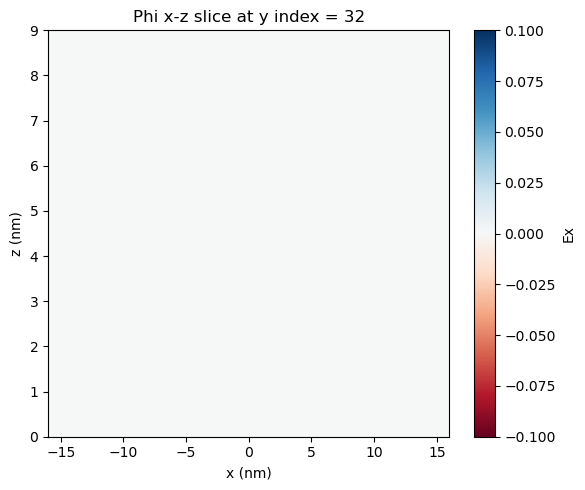

yt : [INFO     ] 2026-06-19 12:03:06,375 Parameters: current_time              = 3.28e-11
yt : [INFO     ] 2026-06-19 12:03:06,375 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:06,376 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:06,376 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


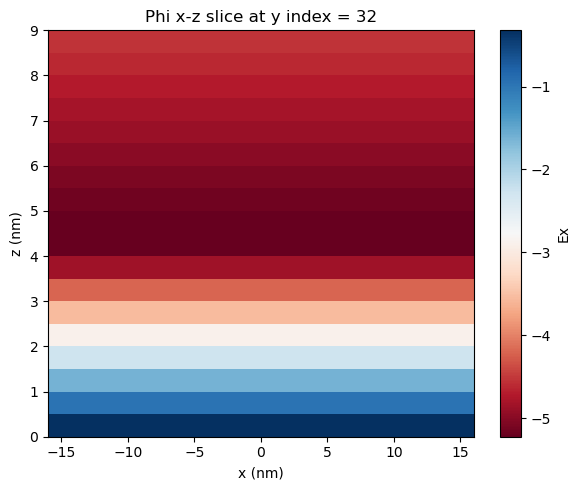

yt : [INFO     ] 2026-06-19 12:03:06,469 Parameters: current_time              = 5.1999999999999995e-11
yt : [INFO     ] 2026-06-19 12:03:06,469 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:06,469 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:06,470 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


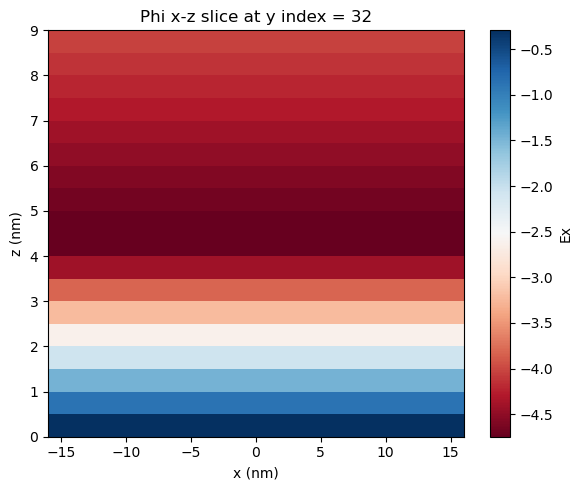

yt : [INFO     ] 2026-06-19 12:03:06,567 Parameters: current_time              = 7.320000000000024e-11
yt : [INFO     ] 2026-06-19 12:03:06,567 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:06,567 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:06,567 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


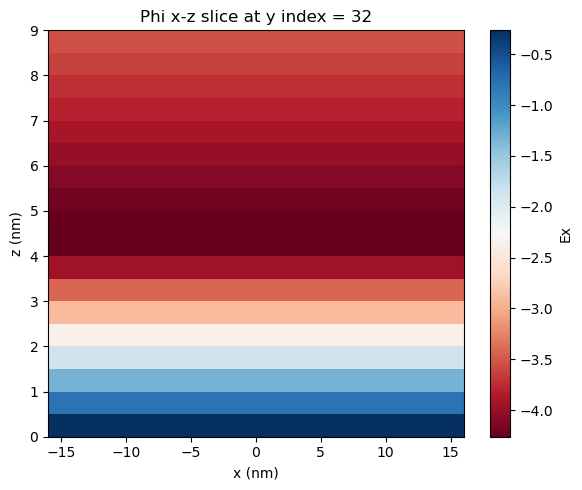

yt : [INFO     ] 2026-06-19 12:03:06,663 Parameters: current_time              = 9.720000000000062e-11
yt : [INFO     ] 2026-06-19 12:03:06,663 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:06,663 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:06,663 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


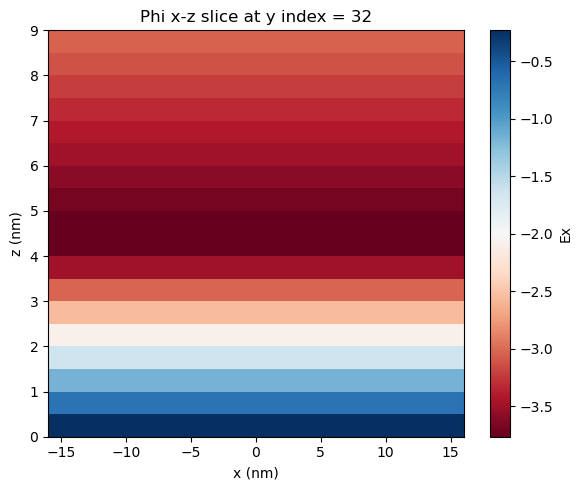

yt : [INFO     ] 2026-06-19 12:03:06,758 Parameters: current_time              = 1.2560000000000079e-10
yt : [INFO     ] 2026-06-19 12:03:06,759 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:06,759 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:06,759 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


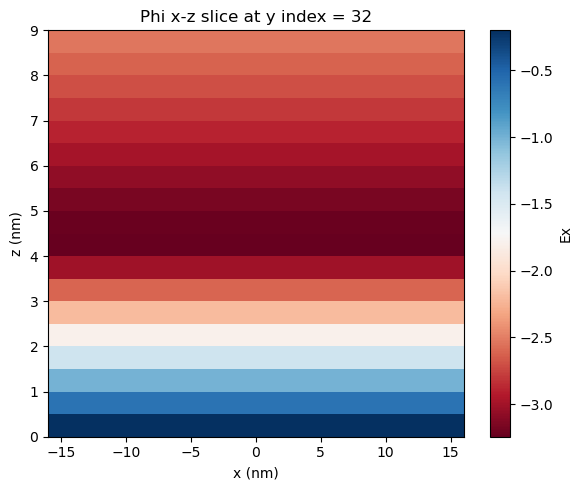

yt : [INFO     ] 2026-06-19 12:03:06,853 Parameters: current_time              = 1.5960000000000023e-10
yt : [INFO     ] 2026-06-19 12:03:06,853 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:06,853 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:06,853 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


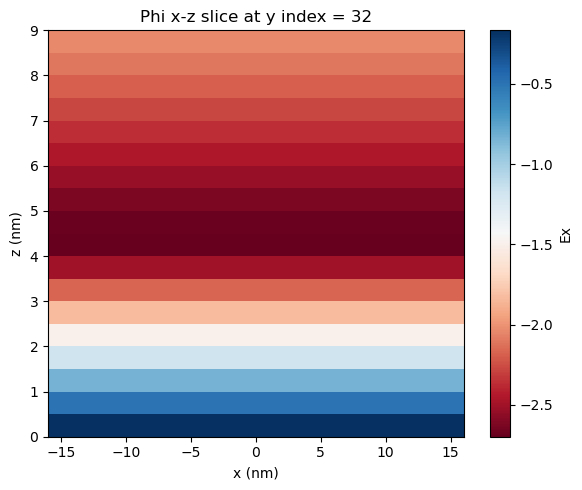

yt : [INFO     ] 2026-06-19 12:03:06,946 Parameters: current_time              = 2.0199999999999954e-10
yt : [INFO     ] 2026-06-19 12:03:06,946 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:06,946 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:06,946 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


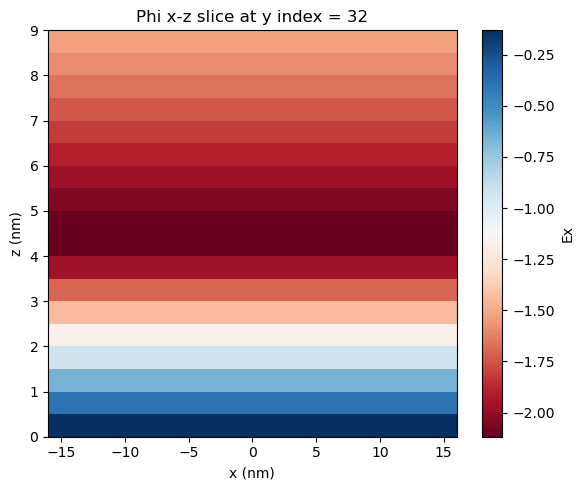

yt : [INFO     ] 2026-06-19 12:03:07,043 Parameters: current_time              = 2.5760000000000023e-10
yt : [INFO     ] 2026-06-19 12:03:07,043 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,043 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,043 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


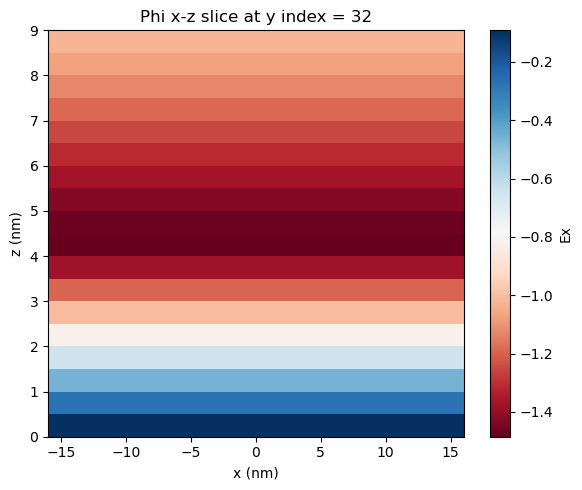

yt : [INFO     ] 2026-06-19 12:03:07,138 Parameters: current_time              = 3.3520000000000397e-10
yt : [INFO     ] 2026-06-19 12:03:07,138 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,139 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,139 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


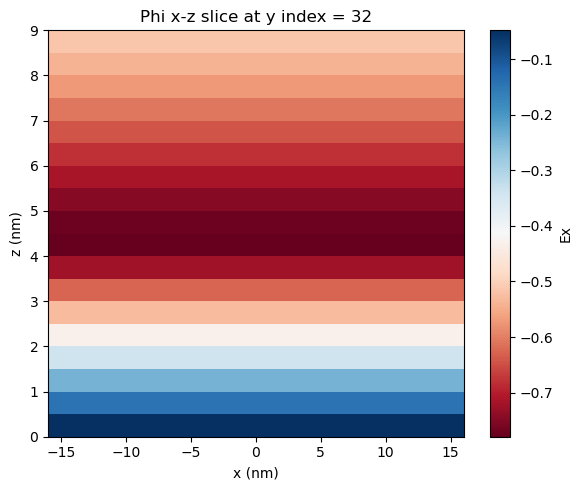

yt : [INFO     ] 2026-06-19 12:03:07,233 Parameters: current_time              = 1.035000000000244e-08
yt : [INFO     ] 2026-06-19 12:03:07,234 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,234 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,234 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


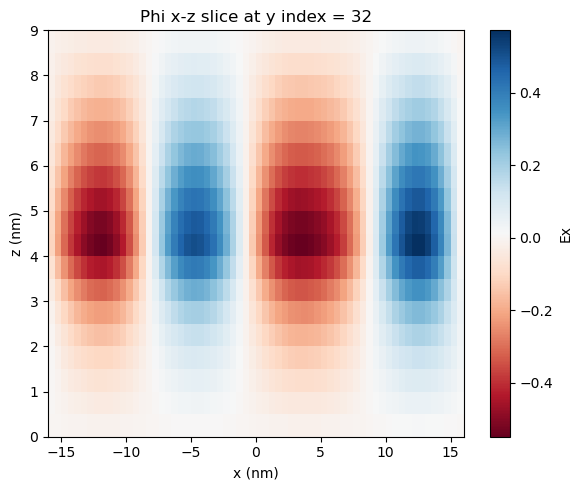

yt : [INFO     ] 2026-06-19 12:03:07,325 Parameters: current_time              = 1.2962000000003241e-08
yt : [INFO     ] 2026-06-19 12:03:07,326 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,326 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,326 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


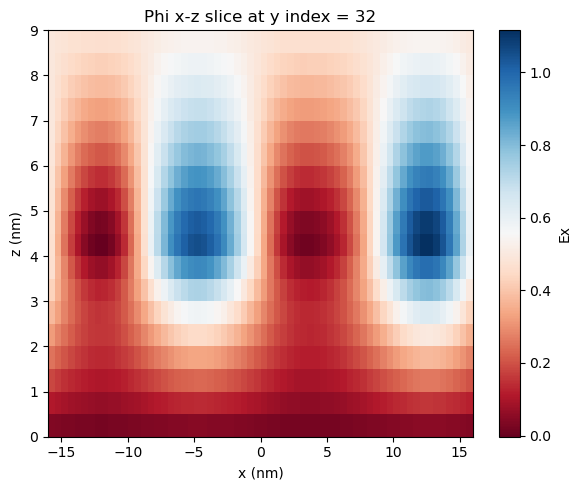

yt : [INFO     ] 2026-06-19 12:03:07,534 Parameters: current_time              = 1.5637600000001015e-08
yt : [INFO     ] 2026-06-19 12:03:07,534 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,534 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,534 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


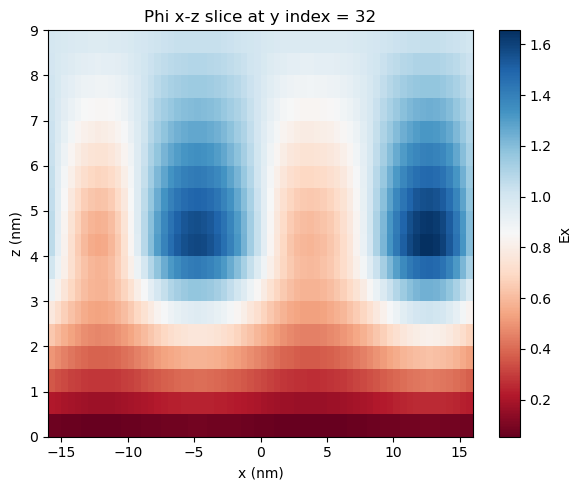

yt : [INFO     ] 2026-06-19 12:03:07,629 Parameters: current_time              = 2.0813599999981195e-08
yt : [INFO     ] 2026-06-19 12:03:07,629 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,629 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,629 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


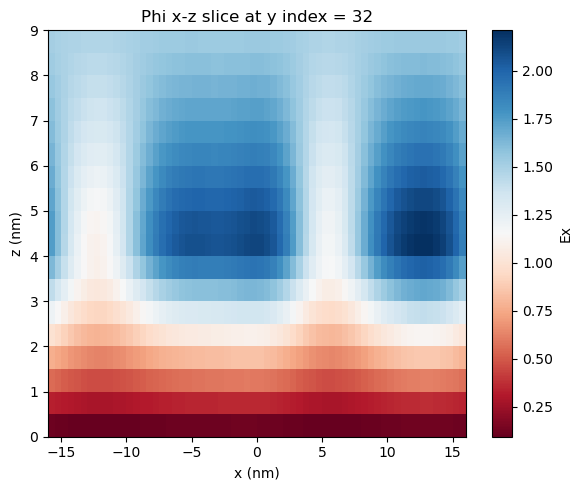

yt : [INFO     ] 2026-06-19 12:03:07,724 Parameters: current_time              = 3.06635999999506e-08
yt : [INFO     ] 2026-06-19 12:03:07,724 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,724 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,724 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


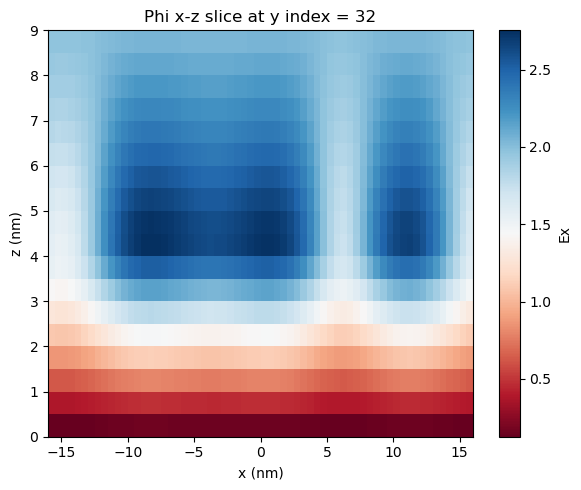

yt : [INFO     ] 2026-06-19 12:03:07,816 Parameters: current_time              = 5.5667600000061685e-08
yt : [INFO     ] 2026-06-19 12:03:07,816 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,817 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,817 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


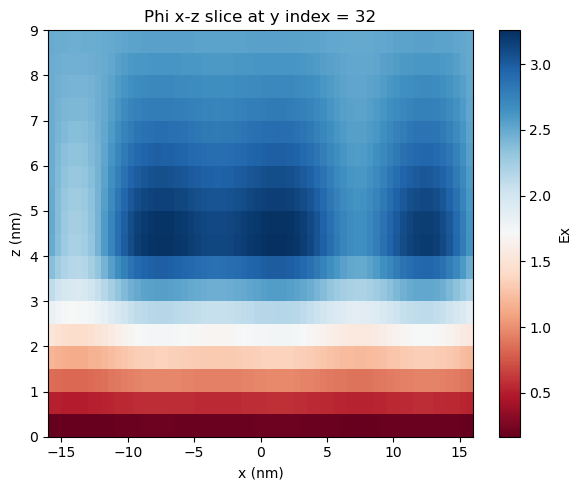

yt : [INFO     ] 2026-06-19 12:03:07,910 Parameters: current_time              = 5.584720000006248e-08
yt : [INFO     ] 2026-06-19 12:03:07,910 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:07,910 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:07,910 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


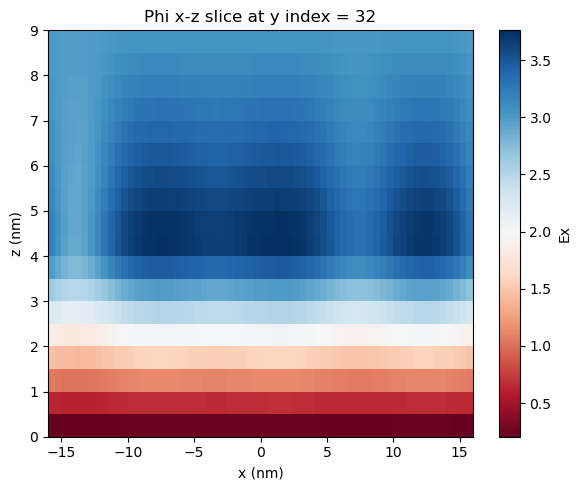

yt : [INFO     ] 2026-06-19 12:03:08,003 Parameters: current_time              = 5.634880000006471e-08
yt : [INFO     ] 2026-06-19 12:03:08,004 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,004 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,004 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


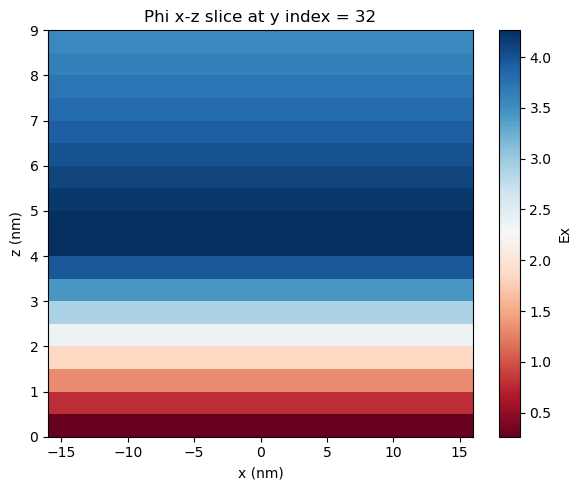

yt : [INFO     ] 2026-06-19 12:03:08,098 Parameters: current_time              = 5.63680000000648e-08
yt : [INFO     ] 2026-06-19 12:03:08,098 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,098 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,098 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


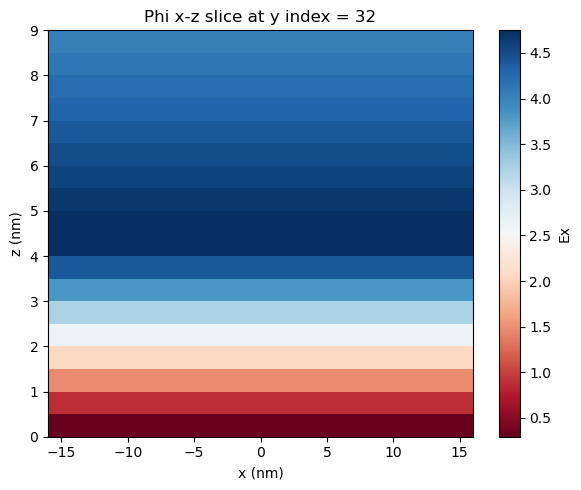

yt : [INFO     ] 2026-06-19 12:03:08,194 Parameters: current_time              = 5.6385200000064873e-08
yt : [INFO     ] 2026-06-19 12:03:08,194 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,194 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,194 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


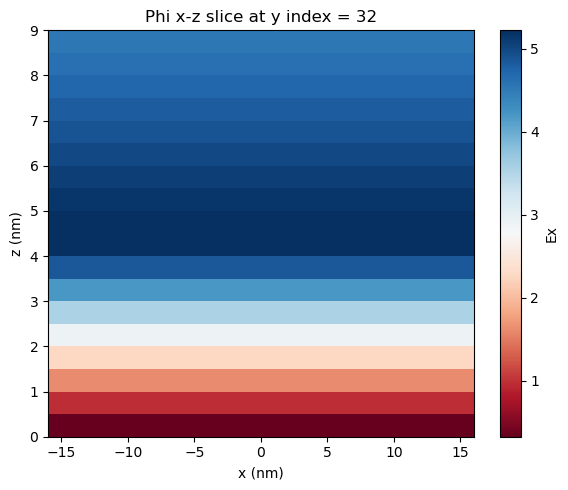

yt : [INFO     ] 2026-06-19 12:03:08,285 Parameters: current_time              = 5.640400000006496e-08
yt : [INFO     ] 2026-06-19 12:03:08,285 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,285 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,285 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


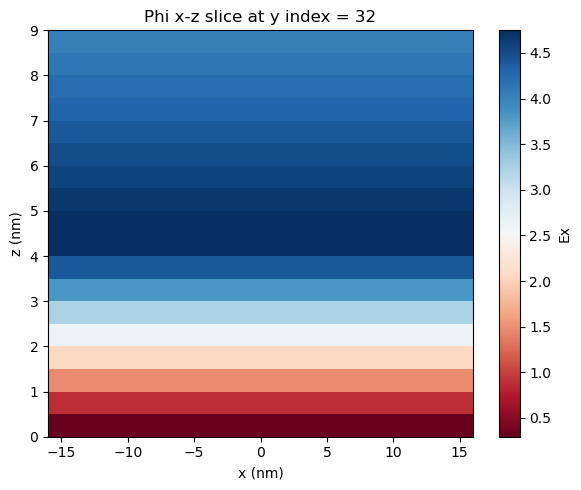

yt : [INFO     ] 2026-06-19 12:03:08,380 Parameters: current_time              = 5.642520000006505e-08
yt : [INFO     ] 2026-06-19 12:03:08,380 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,380 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,380 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


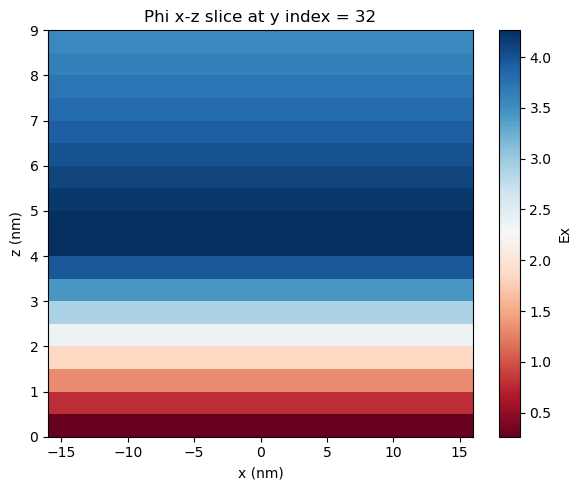

yt : [INFO     ] 2026-06-19 12:03:08,475 Parameters: current_time              = 5.644920000006516e-08
yt : [INFO     ] 2026-06-19 12:03:08,475 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,475 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,475 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


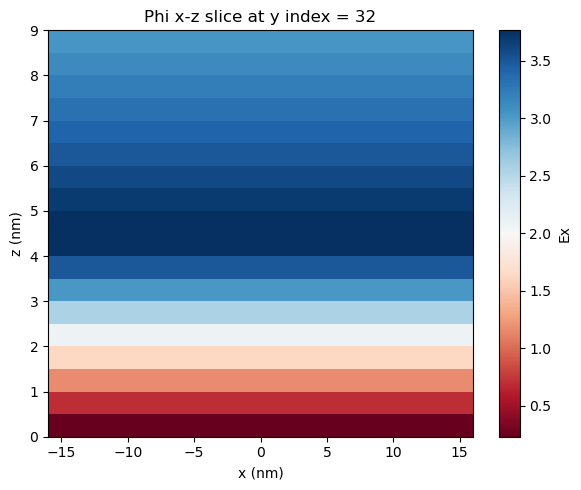

yt : [INFO     ] 2026-06-19 12:03:08,569 Parameters: current_time              = 5.6477600000065284e-08
yt : [INFO     ] 2026-06-19 12:03:08,569 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,569 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,569 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


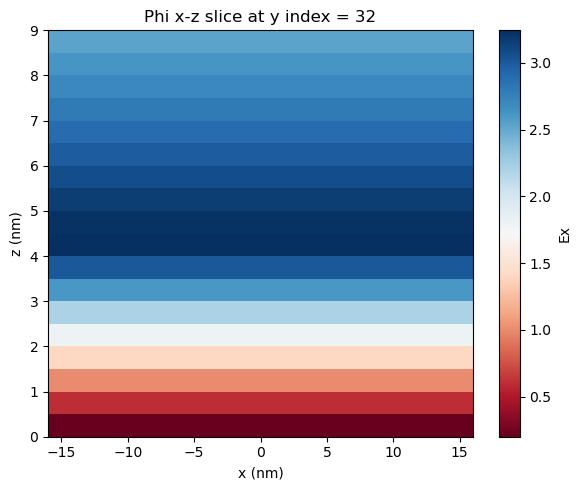

yt : [INFO     ] 2026-06-19 12:03:08,793 Parameters: current_time              = 5.6511600000065435e-08
yt : [INFO     ] 2026-06-19 12:03:08,793 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,793 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,794 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


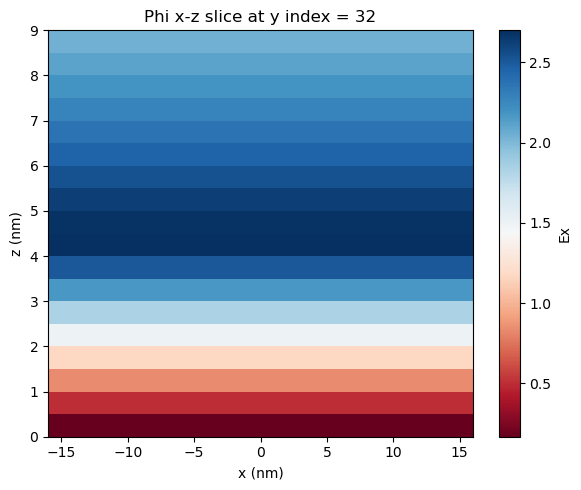

yt : [INFO     ] 2026-06-19 12:03:08,885 Parameters: current_time              = 5.655400000006562e-08
yt : [INFO     ] 2026-06-19 12:03:08,885 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,886 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,886 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


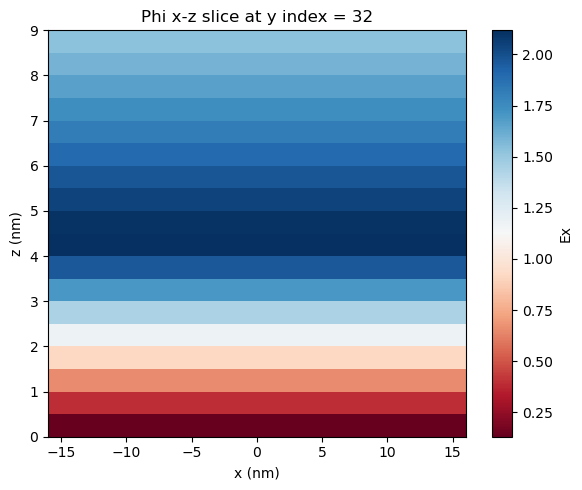

yt : [INFO     ] 2026-06-19 12:03:08,980 Parameters: current_time              = 5.660960000006587e-08
yt : [INFO     ] 2026-06-19 12:03:08,981 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:08,981 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:08,981 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


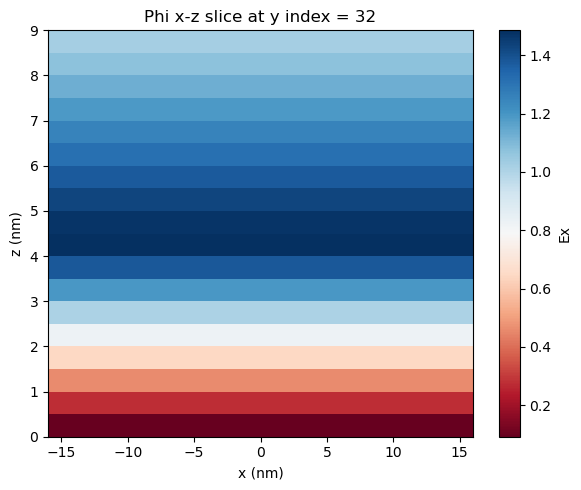

yt : [INFO     ] 2026-06-19 12:03:09,075 Parameters: current_time              = 5.668560000006621e-08
yt : [INFO     ] 2026-06-19 12:03:09,075 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,075 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,075 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


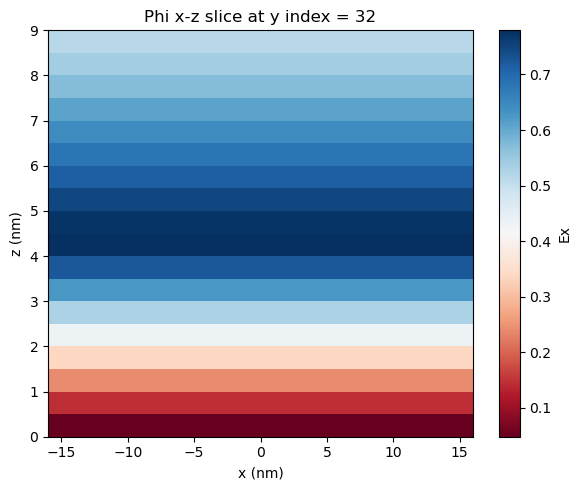

yt : [INFO     ] 2026-06-19 12:03:09,169 Parameters: current_time              = 5.7768000000071017e-08
yt : [INFO     ] 2026-06-19 12:03:09,169 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,169 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,169 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


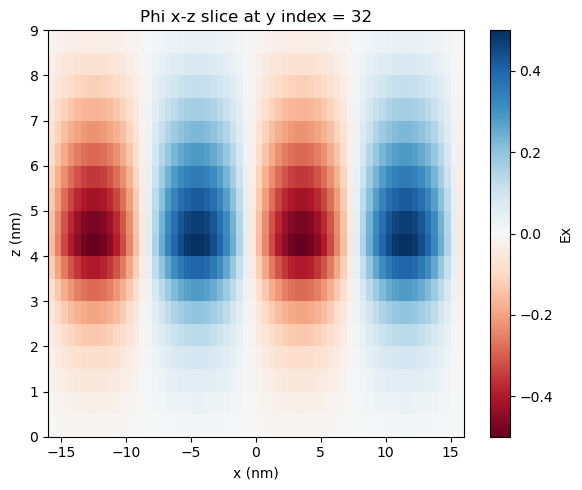

yt : [INFO     ] 2026-06-19 12:03:09,261 Parameters: current_time              = 5.785000000007138e-08
yt : [INFO     ] 2026-06-19 12:03:09,261 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,261 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,261 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


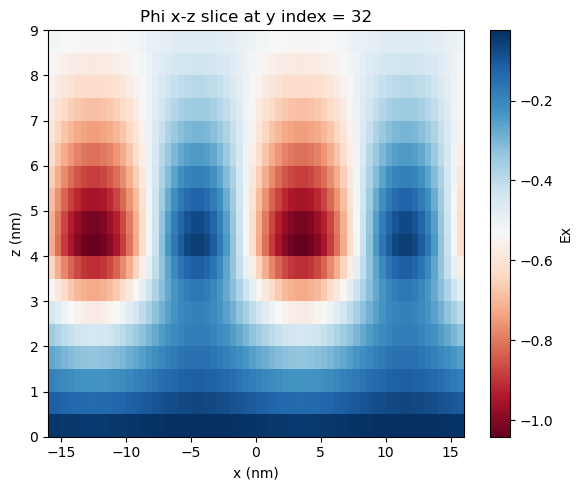

yt : [INFO     ] 2026-06-19 12:03:09,352 Parameters: current_time              = 5.792560000007172e-08
yt : [INFO     ] 2026-06-19 12:03:09,353 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,353 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,353 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


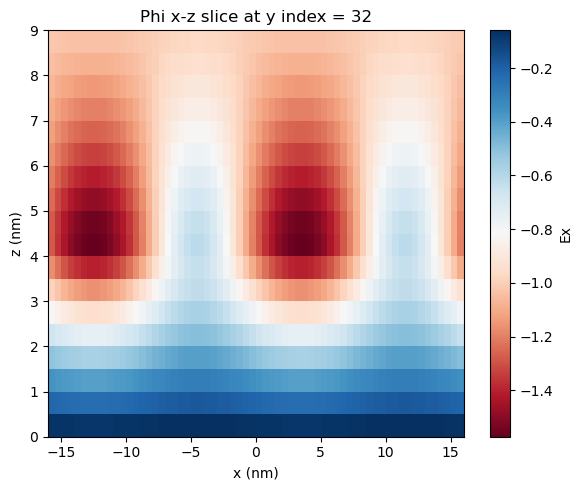

yt : [INFO     ] 2026-06-19 12:03:09,446 Parameters: current_time              = 5.7999600000072046e-08
yt : [INFO     ] 2026-06-19 12:03:09,446 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,447 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,447 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


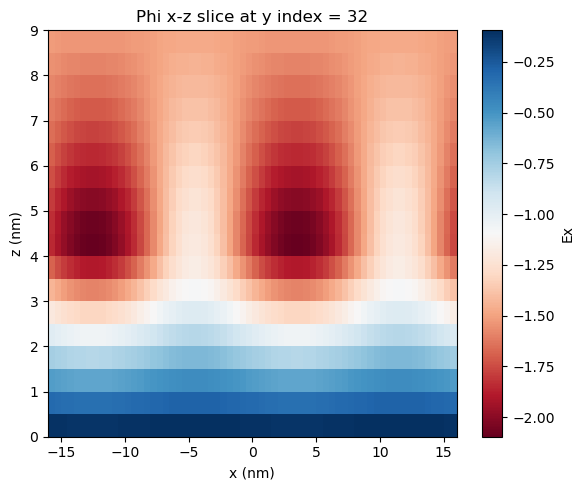

yt : [INFO     ] 2026-06-19 12:03:09,541 Parameters: current_time              = 5.80796000000724e-08
yt : [INFO     ] 2026-06-19 12:03:09,541 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,541 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,542 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


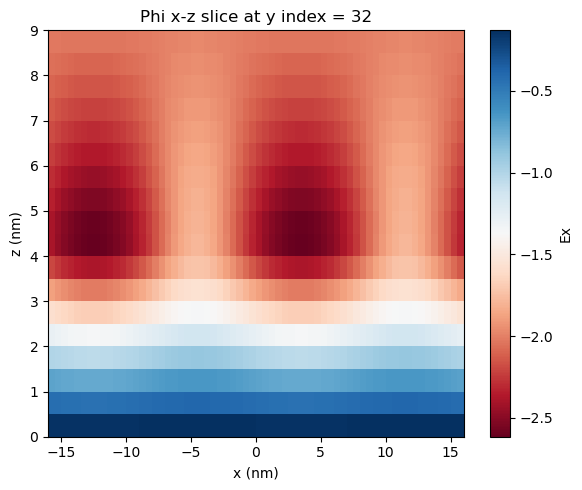

yt : [INFO     ] 2026-06-19 12:03:09,634 Parameters: current_time              = 5.819840000007293e-08
yt : [INFO     ] 2026-06-19 12:03:09,634 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,634 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,635 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


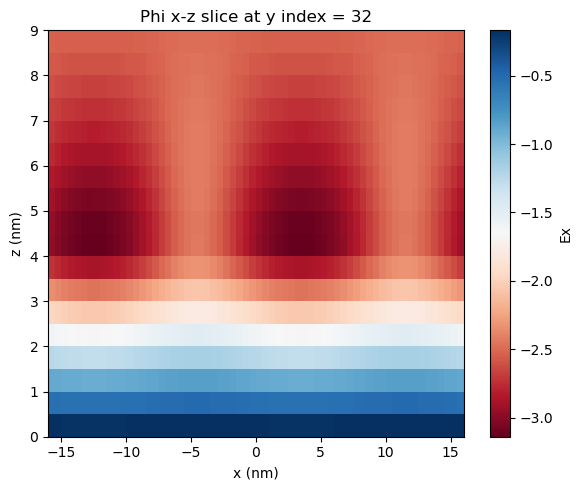

yt : [INFO     ] 2026-06-19 12:03:09,728 Parameters: current_time              = 5.835560000007363e-08
yt : [INFO     ] 2026-06-19 12:03:09,728 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,728 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,728 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


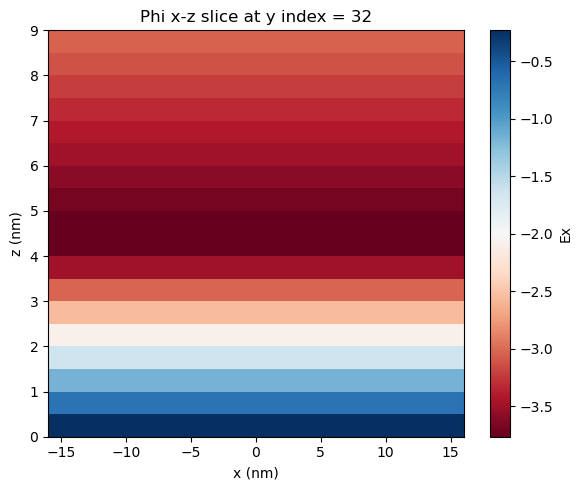

yt : [INFO     ] 2026-06-19 12:03:09,823 Parameters: current_time              = 5.8377600000073725e-08
yt : [INFO     ] 2026-06-19 12:03:09,823 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:09,823 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:09,823 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


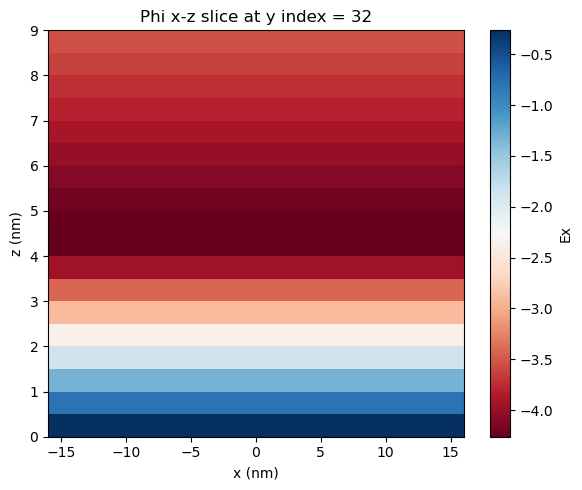

yt : [INFO     ] 2026-06-19 12:03:10,056 Parameters: current_time              = 5.839680000007381e-08
yt : [INFO     ] 2026-06-19 12:03:10,057 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:10,057 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:10,057 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


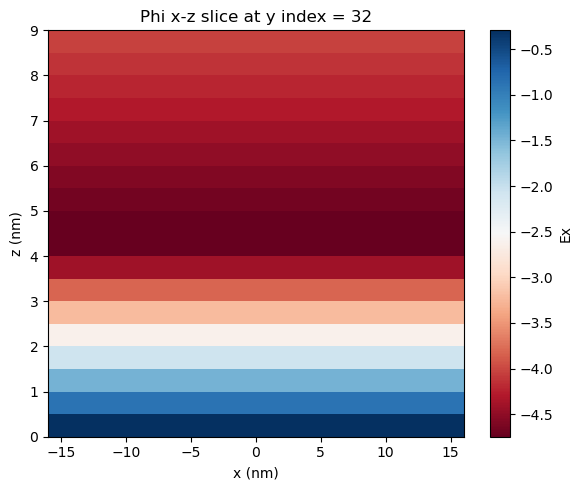

yt : [INFO     ] 2026-06-19 12:03:10,153 Parameters: current_time              = 5.8414000000073887e-08
yt : [INFO     ] 2026-06-19 12:03:10,153 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:10,153 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:10,153 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Phi_array shape = (64, 64, 18)


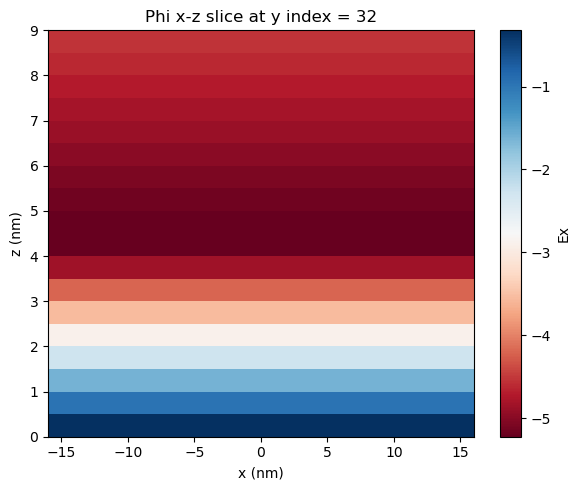

In [14]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-06-19 12:03:10,249 Parameters: current_time              = 5.1999999999999995e-11
yt : [INFO     ] 2026-06-19 12:03:10,249 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:03:10,249 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:03:10,249 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


E_array shape = (64, 64, 18)


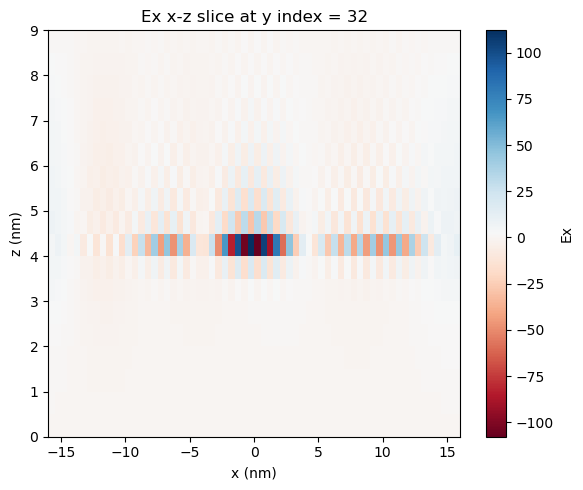

In [15]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-06-19 12:14:28,497 Parameters: current_time              = 3.28e-11
yt : [INFO     ] 2026-06-19 12:14:28,497 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:28,497 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:28,497 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:28,538 Parameters: current_time              = 5.1999999999999995e-11
yt : [INFO     ] 2026-06-19 12:14:28,538 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:28,538 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:28,538 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:28,577 Parameters: current_time              = 7.320000000000024e-11
yt : [INFO     ] 2026-06-19 12:14:28,577 Parameters: domain_dimensions         = [64 

Plotfiles to draw:
  plt00000082
  plt00000130
  plt00000183
  plt00000243
  plt00000314
  plt00000399
  plt00000505
  plt00000644
  plt00000838
  plt00025875
  plt00032405
  plt00039094
  plt00052034
  plt00076659
  plt00139169
  plt00139618
  plt00140872
  plt00140920
  plt00140963
  plt00141010
  plt00141063
  plt00141123
  plt00141194
  plt00141279
  plt00141385
  plt00141524
  plt00141714
  plt00144420
  plt00144625
  plt00144814
  plt00144999
  plt00145199
  plt00145496
  plt00145889
  plt00145944
  plt00145992
  plt00146035


yt : [INFO     ] 2026-06-19 12:14:28,695 Parameters: current_time              = 1.5960000000000023e-10
yt : [INFO     ] 2026-06-19 12:14:28,695 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:28,695 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:28,695 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:28,734 Parameters: current_time              = 2.0199999999999954e-10
yt : [INFO     ] 2026-06-19 12:14:28,734 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:28,735 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:28,735 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:28,773 Parameters: current_time              = 2.5760000000000023e-10
yt : [INFO     ] 2026-06-19 12:14:28,773 Parameters: domain_dimensions

Saved figure: /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/Pz_FE_layer_stack.png


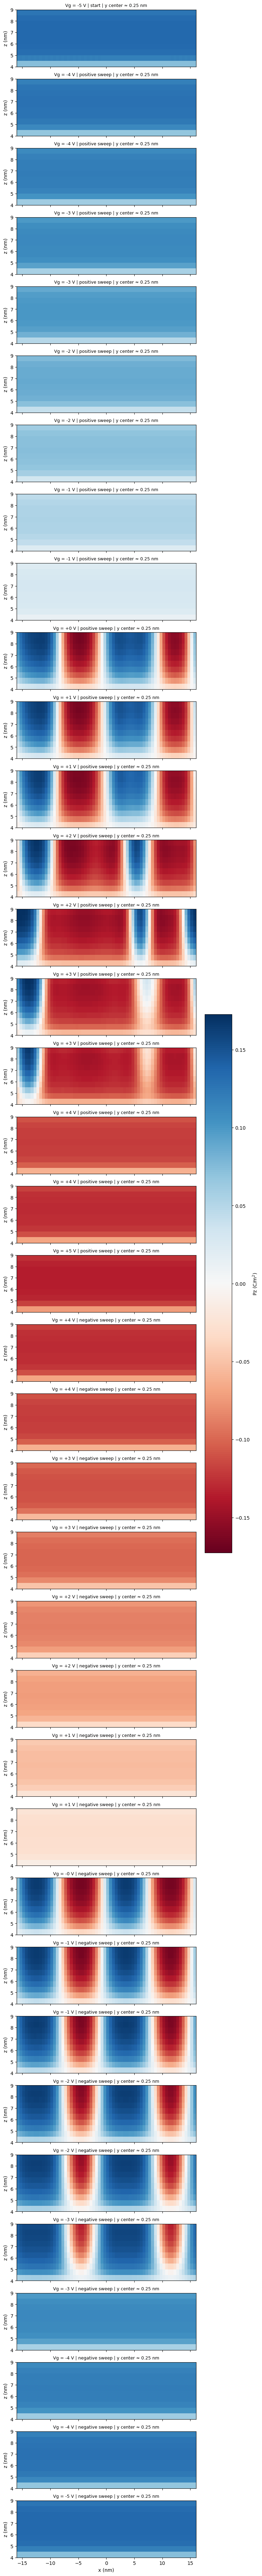

In [16]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")



USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = True

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = PLOT_DIR/"Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid

    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

# figure size
n = len(records)
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)

if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.0f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")

cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## 3D Scatter plot (all voltage in same graph)

* trash

yt : [INFO     ] 2026-06-02 14:39:32,644 Parameters: current_time              = 1.52e-11
yt : [INFO     ] 2026-06-02 14:39:32,645 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-02 14:39:32,645 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-02 14:39:32,646 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-02 14:39:32,753 Parameters: current_time              = 2.4799999999999998e-11
yt : [INFO     ] 2026-06-02 14:39:32,754 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-02 14:39:32,755 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-02 14:39:32,755 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Plotfiles to read:
  plt00000076
  plt00000124
  plt00000178
  plt00000238
  plt00000307
  plt00000389
  plt00000493
  plt00000639
  plt00000911
  plt00001160
  plt00001330
  plt00001378
  plt00001431
  plt00001491
  plt00001560
  plt00001641
  plt00001743
  plt00001886
  plt00002150
  plt00002398
  plt00002575


yt : [INFO     ] 2026-06-02 14:39:32,860 Parameters: current_time              = 3.56000000000001e-11
yt : [INFO     ] 2026-06-02 14:39:32,860 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-02 14:39:32,861 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-02 14:39:32,861 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-02 14:39:32,974 Parameters: current_time              = 4.760000000000029e-11
yt : [INFO     ] 2026-06-02 14:39:32,975 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-02 14:39:32,976 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-02 14:39:32,976 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-02 14:39:33,317 Parameters: current_time              = 6.140000000000042e-11
yt : [INFO     ] 2026-06-02 14:39:33,318 Parameters: domain_dimensio


Read records:
plt00000076  step=76  Vtop=-5.0820 V  Vround=-5  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000124  step=124  Vtop=-4.0882 V  Vround=-4  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000178  step=178  Vtop=-3.0936 V  Vround=-3  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000238  step=238  Vtop=-2.0981 V  Vround=-2  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000307  step=307  Vtop=-1.1012 V  Vround=-1  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000389  step=389  Vtop=-0.1026 V  Vround=-0  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000493  step=493  Vtop=+0.8985 V  Vround=+1  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000639  step=639  Vtop=+1.9041 V  Vround=+2  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000911  step=911  Vtop=+2.9208 V  Vround=+3  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00001160  step=1160  Vtop=+3.9405 V  Vround=+4  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00001330  step=1330  V

/tmp/ipykernel_751268/2315896281.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.03, 0.94, 0.93])



Saved figure: /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_11_plt/Pz_FE_3D_2x11_sweep.png


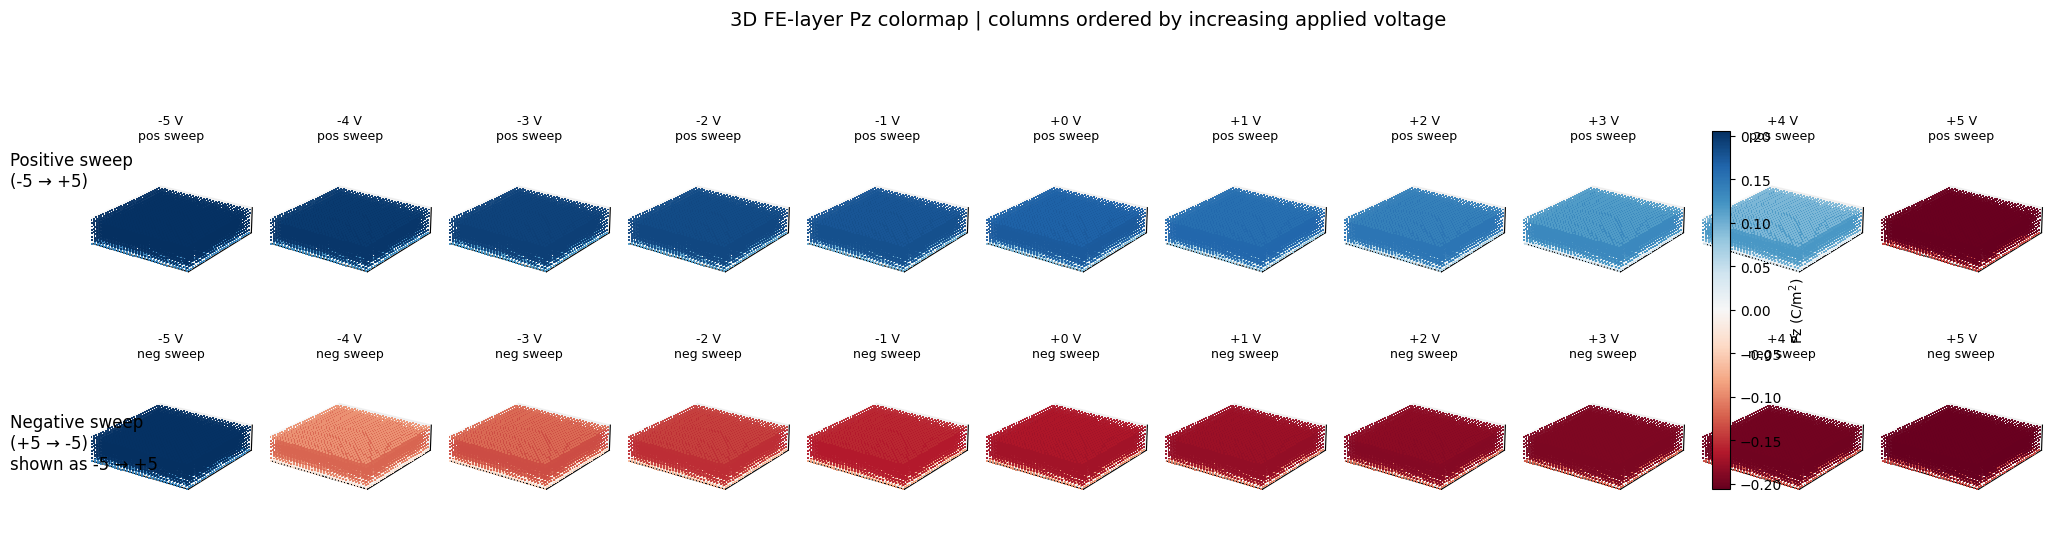

In [15]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 若 FE 只在部分 x/y 範圍，打開這裡
USE_FE_X_RANGE = False

USE_FE_Y_RANGE = False




# 用 top Phi 平均值四捨五入到整數電壓來分類
V_ROUND_DECIMALS = 0

# 3D 點太多會慢，STRIDE=2 表示 x/y/z 每 2 點取 1 點
# 若想更細可設 1；若很慢可設 3 或 4
STRIDE = 2

# 顏色是否以 0 對稱，畫 Pz 建議 True
SYMMETRIC_COLOR_SCALE = True

# 3D 視角
ELEV = 22
AZIM = -55

# 點大小
POINT_SIZE = 2

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 若你已經有 plot_names，就保留 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = False

SAVE_FIG = True
OUT_FIG = PLOT_DIR/"Pz_FE_3D_2x11_sweep.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot_3d(plotfile):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid

    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    # FE selection
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    # Apply selection
    P_fe = P[np.ix_(x_sel, y_sel, z_sel)]

    x_fe = x_nm[x_sel]
    y_fe = y_nm[y_sel]
    z_fe = z_nm[z_sel]

    # Downsample for 3D plotting
    P_ds = P_fe[::STRIDE, ::STRIDE, ::STRIDE]
    x_ds = x_fe[::STRIDE]
    y_ds = y_fe[::STRIDE]
    z_ds = z_fe[::STRIDE]

    X, Y, Z = np.meshgrid(x_ds, y_ds, z_ds, indexing="ij")

    # Estimate top voltage from top cell Phi
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    return {
        "P": P_ds,
        "X": X,
        "Y": Y,
        "Z": Z,
        "x_range": (float(np.min(x_fe)), float(np.max(x_fe))),
        "y_range": (float(np.min(y_fe)), float(np.max(y_fe))),
        "z_range": (float(np.min(z_fe)), float(np.max(z_fe))),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape_full": P.shape,
        "shape_fe": P_fe.shape,
        "shape_plot": P_ds.shape,
    }


def classify_sweep(records):
    """
    根據 records 原本的時間順序，用 Vtop 的變化判斷正掃/負掃。
    第一個點歸到 positive，因為通常是正掃起點。
    turning point 會同時加入 positive 與 negative，讓上下排都有 +5。
    """
    pos = []
    neg = []

    V = np.array([r["Vtop_mean"] for r in records], dtype=float)

    if len(records) == 0:
        return pos, neg

    pos.append(records[0])

    for i in range(1, len(records)):
        dV = V[i] - V[i - 1]

        if dV > 1e-8:
            pos.append(records[i])
        elif dV < -1e-8:
            # 如果剛從正掃轉負掃，把上一個 turning point 也放進 neg
            if len(neg) == 0:
                neg.append(records[i - 1])
            neg.append(records[i])
        else:
            # 同電壓重複時，不確定歸類；先放到目前方向
            if len(neg) == 0:
                pos.append(records[i])
            else:
                neg.append(records[i])

    return pos, neg


def pick_record_by_voltage(records, target_v):
    """
    從一組 records 中挑最接近 target_v 的那筆。
    """
    if len(records) == 0:
        return None

    V = np.array([r["Vround"] for r in records], dtype=float)
    idx = int(np.argmin(np.abs(V - target_v)))

    if np.abs(V[idx] - target_v) > 0.25:
        return None

    return records[idx]


def draw_3d_fe(ax, rec, norm, cmap):
    P = rec["P"]
    X = rec["X"]
    Y = rec["Y"]
    Z = rec["Z"]

    ax.scatter(
        X.ravel(),
        Y.ravel(),
        Z.ravel(),
        c=P.ravel(),
        cmap=cmap,
        norm=norm,
        s=POINT_SIZE,
        marker="s",
        linewidths=0,
        alpha=0.95,
    )

    ax.set_xlim(rec["x_range"])
    ax.set_ylim(rec["y_range"])
    ax.set_zlim(rec["z_range"])

    ax.view_init(elev=ELEV, azim=AZIM)

    # 22 張小圖，不要塞太多刻度
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.set_box_aspect((
        rec["x_range"][1] - rec["x_range"][0],
        rec["y_range"][1] - rec["y_range"][0],
        rec["z_range"][1] - rec["z_range"][0],
    ))


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

print("Plotfiles to read:")
for n in plot_names_use:
    print(" ", n)

records = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot_3d(plotfile)

    Vround = np.round(info["Vtop_mean"], V_ROUND_DECIMALS)

    rec = {
        "name": name,
        "step": get_step_from_name(name),
        "Vround": float(Vround),
        **info,
    }

    records.append(rec)

print("\nRead records:")
for r in records:
    print(
        f"{r['name']}  step={r['step']}  "
        f"Vtop={r['Vtop_mean']:+.4f} V  Vround={r['Vround']:+.0f}  "
        f"shape_fe={r['shape_fe']}  shape_plot={r['shape_plot']}"
    )

# classify positive / negative sweep from time ordering
pos_records, neg_records = classify_sweep(records)

print("\nPositive sweep records:")
for r in pos_records:
    print(f"  V={r['Vround']:+.0f}  {r['name']}")

print("\nNegative sweep records:")
for r in neg_records:
    print(f"  V={r['Vround']:+.0f}  {r['name']}")

# Arrange columns left-to-right by increasing voltage: -5, -4, ..., 5
pos_grid = [pick_record_by_voltage(pos_records, v) for v in VOLTAGES]
neg_grid = [pick_record_by_voltage(neg_records, v) for v in VOLTAGES]

# shared color scale from all selected records
selected_records = [r for r in pos_grid + neg_grid if r is not None]
if len(selected_records) == 0:
    raise RuntimeError("No records selected. Check plot_names or voltage classification.")

all_p = np.concatenate([r["P"].ravel() for r in selected_records])

if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_p))
    vmin = -vmax
else:
    vmin = np.nanmin(all_p)
    vmax = np.nanmax(all_p)

cmap = "RdBu"
norm = Normalize(vmin=vmin, vmax=vmax)

# 2 x 11 figure
fig = plt.figure(figsize=(22, 6.2))

axes = np.empty((2, len(VOLTAGES)), dtype=object)

for row in range(2):
    for col in range(len(VOLTAGES)):
        axes[row, col] = fig.add_subplot(
            2,
            len(VOLTAGES),
            row * len(VOLTAGES) + col + 1,
            projection="3d"
        )

for col, Vtarget in enumerate(VOLTAGES):
    rec = pos_grid[col]
    ax = axes[0, col]

    if rec is not None:
        draw_3d_fe(ax, rec, norm, cmap)
        ax.set_title(f"{Vtarget:+.0f} V\npos sweep", fontsize=9)
    else:
        ax.set_title(f"{Vtarget:+.0f} V\nmissing", fontsize=9)
        ax.axis("off")

for col, Vtarget in enumerate(VOLTAGES):
    rec = neg_grid[col]
    ax = axes[1, col]

    if rec is not None:
        draw_3d_fe(ax, rec, norm, cmap)
        ax.set_title(f"{Vtarget:+.0f} V\nneg sweep", fontsize=9)
    else:
        ax.set_title(f"{Vtarget:+.0f} V\nmissing", fontsize=9)
        ax.axis("off")

# row labels
fig.text(0.01, 0.72, "Positive sweep\n(-5 → +5)", va="center", ha="left", fontsize=12)
fig.text(0.01, 0.28, "Negative sweep\n(+5 → -5)\nshown as -5 → +5", va="center", ha="left", fontsize=12)

# shared colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    shrink=0.75,
    pad=0.01,
    location="right"
)
cbar.set_label(r"Pz (C/m$^2$)")

fig.suptitle(
    "3D FE-layer Pz colormap | columns ordered by increasing applied voltage",
    fontsize=14
)

plt.tight_layout(rect=[0.04, 0.03, 0.94, 0.93])

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"\nSaved figure: {OUT_FIG}")

plt.show()

## 3D Contour plot

* 畫出長方體三個面
* 選擇要畫的三個面C1,C2,C3
* 選擇視角

yt : [INFO     ] 2026-06-19 12:54:53,309 Parameters: current_time              = 2.0813599999981195e-08
yt : [INFO     ] 2026-06-19 12:54:53,309 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:54:53,309 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:54:53,310 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]



Saved figure: /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/Pz_FE_3D_contour.png


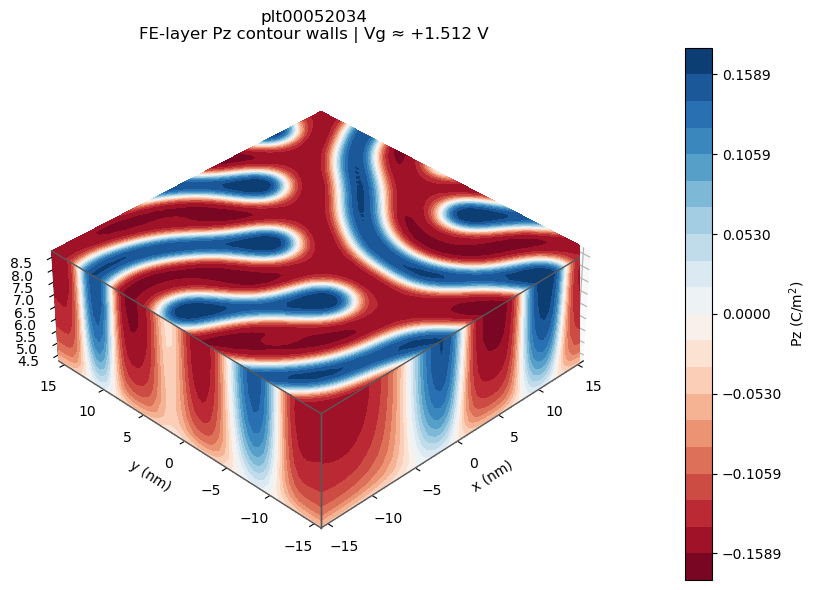

In [29]:
from pathlib import Path

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")
   # 改成你要畫的 plotfile

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 只想取部分 x/y 範圍
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False


# contour levels
N_LEVELS = 21

# 視角
ELEV = 35
AZIM = 225

# 色階是否對稱於 0
SYMMETRIC_COLOR_SCALE = True

SAVE_FIG= True
OUT_FIG = PLOT_DIR/"Pz_FE_3D_contour.png"

# ==========================
# Helper
# ==========================

def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


# ==========================
# Load data
# ==========================

plotfile = PLOT_DIR / PLOTFILE_NAME
ds = yt.load(str(plotfile))
g = ds.index.grids[0]

P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid

if PHI_FIELD in ds.field_list:
    Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
else:
    Phi = None

Nx, Ny, Nz = P.shape

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dx = (hi - lo) / np.array([Nx, Ny, Nz])

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9


# ==========================
# Select FE layer
# ==========================

z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

if USE_FE_X_RANGE:
    x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
else:
    x_sel = np.ones_like(x_nm, dtype=bool)

if USE_FE_Y_RANGE:
    y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
else:
    y_sel = np.ones_like(y_nm, dtype=bool)

P_fe = P[np.ix_(x_sel, y_sel, z_sel)]

x_fe = x_nm[x_sel]
y_fe = y_nm[y_sel]
z_fe = z_nm[z_sel]

Nx_fe, Ny_fe, Nz_fe = P_fe.shape

# 選三個切面：
# xy plane at top FE surface
k_top = Nz_fe - 1

# xz plane at y min side
#j_mid = Ny_fe // 2

# yz plane at x max side
i_right = Nx_fe - 1

P_xy = P_fe[:, :, k_top]      # shape (Nx, Ny)
P_xz = P_fe[:, 0, :]      # shape (Nx, Nz)
P_yz = P_fe[i_right, :, :]    # shape (Ny, Nz)

# 建立 2D coordinates
X_xy, Y_xy = np.meshgrid(x_fe, y_fe, indexing="ij")
X_xz, Z_xz = np.meshgrid(x_fe, z_fe, indexing="ij")
Y_yz, Z_yz = np.meshgrid(y_fe, z_fe, indexing="ij")


# ==========================
# Voltage label
# ==========================

if Phi is not None:
    top_phi = Phi[:, :, -1]
    Vtop_mean = float(np.mean(top_phi))
else:
    Vtop_mean = np.nan


# ==========================
# Color scale
# ==========================

if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(P_fe))
    vmin = -vmax
else:
    vmin = np.nanmin(P_fe)
    vmax = np.nanmax(P_fe)

levels = np.linspace(vmin, vmax, N_LEVELS)

kw = dict(
    levels=levels,
    vmin=vmin,
    vmax=vmax,
    cmap="RdBu",
)


# ==========================
# Plot 3D contour walls
# ==========================

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

xmin, xmax = x_fe.min(), x_fe.max()
ymin, ymax = y_fe.min(), y_fe.max()
zmin, zmax = z_fe.min(), z_fe.max()

# 1. xy plane, placed at z = zmax
# contourf expects arrays with same shape.
# X_xy/Y_xy/P_xy are (Nx, Ny)
C1 = ax.contourf(
    X_xy,
    Y_xy,
    P_xy,
    zdir="z",
    offset=zmax,
    **kw
)

# 2. xz plane, placed at y = ymin
# Here x-axis is X_xz, vertical is Z_xz, color is P_xz
C2 = ax.contourf(
    X_xz,
    P_xz,
    Z_xz,
    zdir="y",
    offset=ymin,
    **kw
)

# 3. yz plane, placed at x = xmax
# Here horizontal axis is Y_yz, vertical is Z_yz, color is P_yz
C3 = ax.contourf(
    P_yz,
    Y_yz,
    Z_yz,
    zdir="x",
    offset=xmin,
    **kw
)

# Set axis limits
ax.set(
    xlim=[xmin, xmax],
    ylim=[ymin, ymax],
    zlim=[zmin, zmax],
)

# Draw box edges
edges_kw = dict(color="0.35", linewidth=1.0, zorder=1000)

# 只畫可見的外框邊，不畫背後被內容遮住的線
visible_edges = [
    # bottom/front-ish edges（左側變主視角）
    ([xmin, xmax], [ymin, ymin], [zmin, zmin]),
    ([xmin, xmin], [ymin, ymax], [zmin, zmin]),
    ([xmin, xmin], [ymin, ymin], [zmin, zmax]),

    # top/front-ish edges
    ([xmin, xmax], [ymin, ymin], [zmax, zmax]),
    ([xmin, xmin], [ymin, ymax], [zmax, zmax]),
    ([xmin, xmin], [ymin, ymin], [zmin, zmax]),
]

for xs, ys, zs in visible_edges:
    ax.plot(xs, ys, zs, **edges_kw)
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_zlabel("z (nm)")

ax.view_init(ELEV, AZIM)
Z_VISUAL_SCALE = 2.5
ax.set_box_aspect((
    xmax - xmin,
    ymax - ymin,
    Z_VISUAL_SCALE * (zmax - zmin)
))

ax.set_title(
    f"{PLOTFILE_NAME}\n"
    f"FE-layer Pz contour walls | Vg ≈ {Vtop_mean:+.3f} V"
)

cbar = fig.colorbar(C3, ax=ax, fraction=0.035, pad=0.12)
cbar.set_label(r"Pz (C/m$^2$)")

plt.tight_layout()

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=300)
    print(f"\nSaved figure: {OUT_FIG}")

plt.show()

## PV

In [18]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = PLOT_DIR/"MFIS_PV_curve.csv"
OUT_FIG = PLOT_DIR/"MFIS_PV_curve.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-06-19 12:14:37,141 Parameters: current_time              = 3.28e-11
yt : [INFO     ] 2026-06-19 12:14:37,141 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:37,141 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:37,141 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:37,182 Parameters: current_time              = 5.1999999999999995e-11
yt : [INFO     ] 2026-06-19 12:14:37,182 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:37,183 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:37,183 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Finding plotfiles in /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1...
['plt00000082', 'plt00000130', 'plt00000183', 'plt00000243', 'plt00000314', 'plt00000399', 'plt00000505', 'plt00000644', 'plt00000838', 'plt00025875', 'plt00032405', 'plt00039094', 'plt00052034', 'plt00076659', 'plt00139169', 'plt00139618', 'plt00140872', 'plt00140920', 'plt00140963', 'plt00141010', 'plt00141063', 'plt00141123', 'plt00141194', 'plt00141279', 'plt00141385', 'plt00141524', 'plt00141714', 'plt00144420', 'plt00144625', 'plt00144814', 'plt00144999', 'plt00145199', 'plt00145496', 'plt00145889', 'plt00145944', 'plt00145992', 'plt00146035']
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00000082
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00000082 | step=82 | Vg=-4.5483 V | <Pz>_FE=+1.261183e-01


yt : [INFO     ] 2026-06-19 12:14:37,424 Parameters: current_time              = 7.320000000000024e-11
yt : [INFO     ] 2026-06-19 12:14:37,424 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:37,424 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:37,424 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:37,464 Parameters: current_time              = 9.720000000000062e-11
yt : [INFO     ] 2026-06-19 12:14:37,464 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:37,464 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:37,464 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:37,503 Parameters: current_time              = 1.2560000000000079e-10
yt : [INFO     ] 2026-06-19 12:14:37,503 Parameters: domain_dimensions  

Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00000130
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00000130 | step=130 | Vg=-4.0479 V | <Pz>_FE=+1.186569e-01
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00000183
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00000183 | step=183 | Vg=-3.5469 V | <Pz>_FE=+1.104650e-01
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00000243
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00000243 | step=243 | Vg=-3.0451 V | <Pz>_FE=+1.013583e-01
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00000314
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00000314 | step=314 | Vg=-2.5423 V | <Pz>_FE=+9.107085e-02
Read Pz with sha

yt : [INFO     ] 2026-06-19 12:14:37,622 Parameters: current_time              = 2.5760000000000023e-10
yt : [INFO     ] 2026-06-19 12:14:37,622 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:37,622 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:37,622 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:37,662 Parameters: current_time              = 3.3520000000000397e-10
yt : [INFO     ] 2026-06-19 12:14:37,662 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:37,663 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:37,663 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:37,702 Parameters: current_time              = 1.035000000000244e-08
yt : [INFO     ] 2026-06-19 12:14:37,702 Parameters: domain_dimensions 

...

Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00141385
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00141385 | step=141385 | Vg=+1.5326 V | <Pz>_FE=-6.514071e-02
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00141524
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00141524 | step=141524 | Vg=+1.0247 V | <Pz>_FE=-4.790307e-02
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00141714
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00141714 | step=141714 | Vg=+0.5138 V | <Pz>_FE=-2.620173e-02
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00144420
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00144420 | step=144420 | Vg=-0.0000 V | <Pz>_FE=-5.464379e-18
Read

yt : [INFO     ] 2026-06-19 12:14:38,543 Parameters: current_time              = 5.7999600000072046e-08
yt : [INFO     ] 2026-06-19 12:14:38,543 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:38,543 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:38,543 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:38,582 Parameters: current_time              = 5.80796000000724e-08
yt : [INFO     ] 2026-06-19 12:14:38,583 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:38,583 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:38,583 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-06-19 12:14:38,622 Parameters: current_time              = 5.819840000007293e-08
yt : [INFO     ] 2026-06-19 12:14:38,622 Parameters: domain_dimensions   

Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00144999
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00144999 | step=144999 | Vg=-1.5101 V | <Pz>_FE=+3.841359e-02
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00145199
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00145199 | step=145199 | Vg=-2.0136 V | <Pz>_FE=+5.149764e-02
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00145496
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00145496 | step=145496 | Vg=-2.5182 V | <Pz>_FE=+6.598244e-02
Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00145889
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00145889 | step=145889 | Vg=-3.0451 V | <Pz>_FE=+1.013571e-01
Read

yt : [INFO     ] 2026-06-19 12:14:38,781 Parameters: current_time              = 5.8414000000073887e-08
yt : [INFO     ] 2026-06-19 12:14:38,781 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-06-19 12:14:38,781 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-19 12:14:38,782 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


Read Pz with shape (64, 64, 18) from /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/plt00146035
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 9.000e-09] m
plt00146035 | step=146035 | Vg=-4.5483 V | <Pz>_FE=+1.261173e-01
Saved CSV: /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/MFIS_PV_curve.csv


Saved figure: /home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/MFIS_PV_curve.png


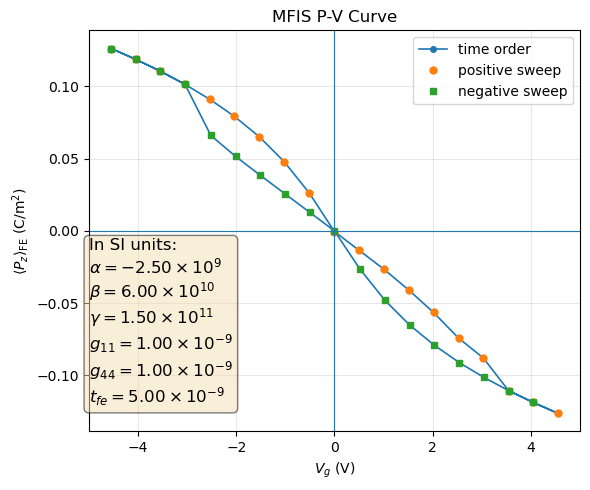

In [19]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(-5, -0.005, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, P, "-o", markersize=4, linewidth=1.2, label="time order")

# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], P[pos], "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], P[neg], "s", markersize=5, label="negative sweep")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (C/m$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()